In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score
from sklearn.neighbors import NearestNeighbors

In [2]:
# 1. LOAD DATA & CHECK INITIAL CLASS IMBALANCE
df = pd.read_csv('fraud_smote.csv')
print("--- Initial Class Distribution ---")
print(df['Fraud'].value_counts())
print(df['Fraud'].value_counts(normalize=True))

X = df.drop('Fraud', axis=1)
y = df['Fraud']
# Stratified split to maintain fraud ratio in test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

--- Initial Class Distribution ---
Fraud
0    110
1     10
Name: count, dtype: int64
Fraud
0    0.916667
1    0.083333
Name: proportion, dtype: float64


In [3]:
# 2. APPLY SMOTE (Synthetic Minority Over-sampling Technique)
def apply_smote_manual(X_train, y_train):
    X_minority = X_train[y_train == 1].values
    n_to_generate = sum(y_train == 0) - sum(y_train == 1)

    # Use Nearest Neighbors to find points to interpolate between
    # Using k=2 because the minority class in this specific CSV is very small
    nn = NearestNeighbors(n_neighbors=min(len(X_minority)-1, 3))
    nn.fit(X_minority)

    synthetic_samples = []
    for _ in range(n_to_generate):
        idx = np.random.randint(0, len(X_minority))
        sample = X_minority[idx]

        # Find neighbors and pick one at random
        neighbors = nn.kneighbors([sample], return_distance=False)
        neighbor_idx = np.random.choice(neighbors[0][1:]) if len(neighbors[0]) > 1 else neighbors[0][0]
        neighbor = X_minority[neighbor_idx]

        # Create a new synthetic point along the line between sample and neighbor
        alpha = np.random.random()
        synthetic_samples.append(sample + alpha * (neighbor - sample))

    X_resampled = np.vstack([X_train.values, np.array(synthetic_samples)])
    y_resampled = np.hstack([y_train.values, np.ones(n_to_generate)])
    return X_resampled, y_resampled

X_train_smote, y_train_smote = apply_smote_manual(X_train, y_train)
print("\n--- Distribution After SMOTE (Train Set) ---")
print(pd.Series(y_train_smote).value_counts())


--- Distribution After SMOTE (Train Set) ---
1.0    88
0.0    88
Name: count, dtype: int64


In [4]:
# 3. TRAIN MODELS BEFORE & AFTER SMOTE
# Model 1: Imbalanced Data
clf_before = RandomForestClassifier(random_state=42)
clf_before.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
# Model 2: Balanced Data
clf_after = RandomForestClassifier(random_state=42)
clf_after.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
# 4. COMPARE PERFORMANCE
print("\n--- Performance BEFORE SMOTE ---")
print(classification_report(y_test, clf_before.predict(X_test)))

print("\n--- Performance AFTER SMOTE ---")
print(classification_report(y_test, clf_after.predict(X_test)))


--- Performance BEFORE SMOTE ---
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24


--- Performance AFTER SMOTE ---
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        22
           1       0.00      0.00      0.00         2

    accuracy                           0.83        24
   macro avg       0.45      0.45      0.45        24
weighted avg       0.83      0.83      0.83        24



E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2742: Use

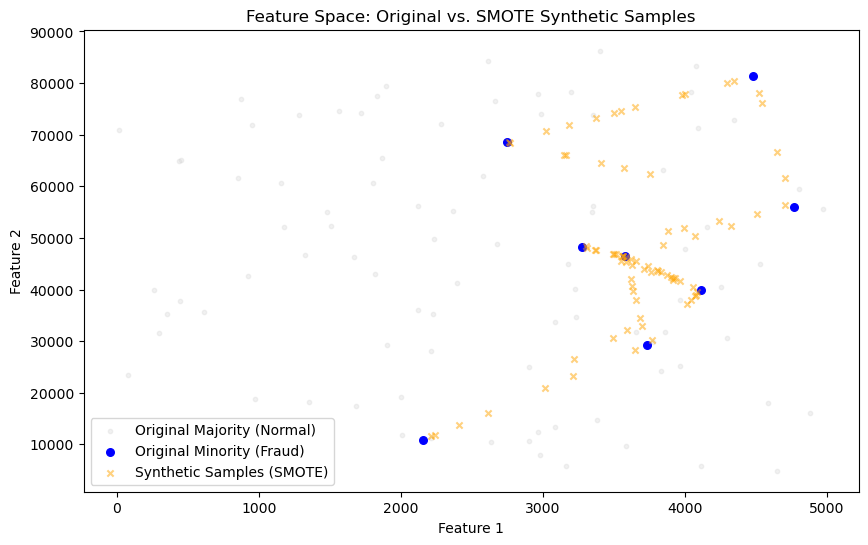

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


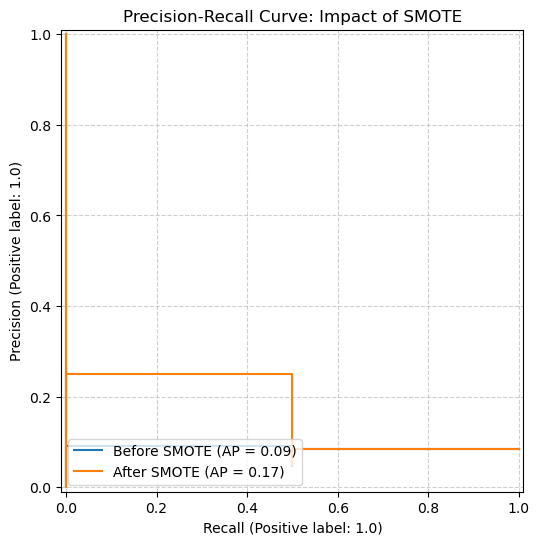

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


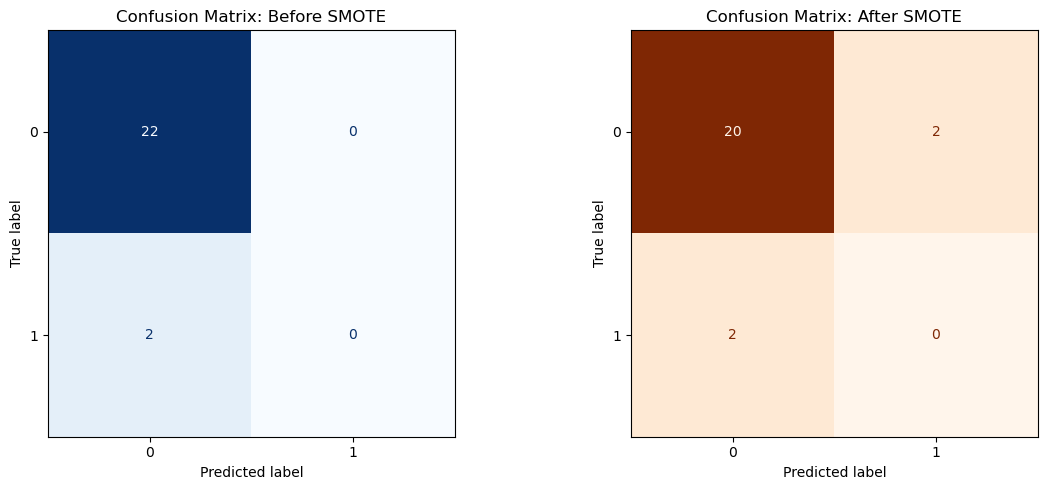

In [9]:
# --- 5. Advanced SMOTE Visualizations ---

# A. Visualizing Synthetic vs Original Data (Feature Space)
# We pick the first two features to show the "interpolation" effect
plt.figure(figsize=(10, 6))

# Plot original majority class
plt.scatter(X_train.values[y_train == 0, 0], X_train.values[y_train == 0, 1], 
            label='Original Majority (Normal)', alpha=0.3, c='lightgrey', s=10)

# Plot original minority class
plt.scatter(X_train.values[y_train == 1, 0], X_train.values[y_train == 1, 1], 
            label='Original Minority (Fraud)', alpha=1, c='blue', s=30)

# Plot synthetic samples (they will appear in lines between original minority points)
X_synthetic = X_train_smote[len(X_train):]
plt.scatter(X_synthetic[:, 0], X_synthetic[:, 1], 
            label='Synthetic Samples (SMOTE)', alpha=0.5, c='orange', s=20, marker='x')

plt.title('Feature Space: Original vs. SMOTE Synthetic Samples')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

# B. Precision-Recall Curve Comparison
# Essential for fraud because Accuracy is misleading
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(8, 6))

PrecisionRecallDisplay.from_estimator(clf_before, X_test, y_test, ax=ax, name="Before SMOTE")
PrecisionRecallDisplay.from_estimator(clf_after, X_test, y_test, ax=ax, name="After SMOTE")

plt.title('Precision-Recall Curve: Impact of SMOTE')
plt.grid(linestyle='--', alpha=0.6)
plt.show()

# C. Confusion Matrix Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_before = confusion_matrix(y_test, clf_before.predict(X_test))
cm_after = confusion_matrix(y_test, clf_after.predict(X_test))

ConfusionMatrixDisplay(cm_before).plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title('Confusion Matrix: Before SMOTE')

ConfusionMatrixDisplay(cm_after).plot(ax=ax2, cmap='Oranges', colorbar=False)
ax2.set_title('Confusion Matrix: After SMOTE')

plt.tight_layout()
plt.show()